# 공동저자 워크스루 — Imputation 리비전 (누수 없는 재평가)

> **VS Code에서 위→아래로 셀을 하나씩 실행하며 설명하는 프레젠테이션용 노트북입니다.**
> 새 실험은 없습니다. 기존 결과·원본 코드를 **로드/시각화만** 합니다.
> 모든 파일 로드는 `try/except`로 감싸져 있어, 파일이 없으면 "결과 없음" 안내로 대체하고 계속 진행합니다.
> 숫자·프레이밍은 `COAUTHOR_MEMO.md` / `REVISION_PLAN.md` / `THEORY_SKETCH.md` 와 일치시켰습니다.

작성 2026-07 · 브랜치 `revision-or-2026`

## 0. 미팅 개요

**오늘의 결론 (bottom line):**
누수 없는 엄격한 재평가에서 **원 논문의 중심 주장(SAM이 오차지표에서 최고)은 성립하지 않는다.**
살아남은 기여는 더 좁지만 실재한다 — **효율적·이식 가능한 순서일관성 LP(monotonization, Thm 1, O(m))** 와 **문헌의 느슨한 관행을 바로잡은 엄격한 재평가**.
→ 권고: **겸손하지만 정직한 방법론 논문(JORS 지향)으로 재프레이밍.**

**오늘 답할 5개 질문:**

1. **우리 실험의 무엇이 잘못됐나?** — 설명이 아니라 *코드와 원 논문 숫자*로 (fold 비-disjoint, 유사도 누수).
2. **정정하면 무슨 일이 일어나나?** — 주장의 **단조 축소** 사다리.
3. **monotonization이 문제인가?** — 아니다(무죄). 약한 고리는 **aggregation**.
4. **왜 α(case amplification)/NQA가 우리 데이터에선 안 통했나?** — 두 겹의 이유(구조 + 알고리즘), 2026 실증.
5. **무엇이 살아남고, 앞으로 뭘 하나?** — LP 연산자로 재프레이밍 + 잔여 갭 + 공동저자 결정 3가지.

### 셋업 — 경로 정의 · imputation_2026 자동 탐색 · 문서 기준 숫자

*이 셀에서 무엇을 보이는가:* 모든 경로를 변수로 한 번만 정의하고, `imputation_2026`을 자동 탐색(로컬 → clone → 미연결)하며,
CSV가 없을 때 대체로 쓸 **문서 기준 숫자**(COAUTHOR_MEMO / REVISION_PLAN / THEORY_SKETCH)를 딕셔너리로 고정합니다.
마지막에 무엇이 연결됐는지 상태표를 출력합니다.

In [1]:
import os, glob, json, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
pd.set_option("display.max_columns", 40)

# 한글 라벨 렌더링 (macOS: AppleGothic). 실패해도 진행.
try:
    plt.rcParams["font.family"] = "AppleGothic"
except Exception:
    pass
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# ---- 경로 (상대경로, 노트북은 revision/meeting/ 에서 실행된다고 가정) ----
# 저장소 루트로 올라가는 경로를 견고하게 탐색
def _find_repo_root():
    here = os.path.abspath(os.getcwd())
    cur = here
    for _ in range(6):
        if os.path.isdir(os.path.join(cur, "Imputation")):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    return here  # 못 찾으면 현재 위치

ROOT    = _find_repo_root()
ORIG    = os.path.join(ROOT, "Imputation")            # 원본 코드 (수정 금지, 참조만)
RESULTS = os.path.join(ROOT, "revision", "results")   # 정정 후 결과 CSV (있으면 로드)
TOY     = os.path.join(ROOT, "revision", "toy")       # toy 검증 CSV (있으면 로드)

print("ROOT   :", ROOT)
print("ORIG   :", ORIG, "  존재:", os.path.isdir(ORIG))
print("RESULTS:", RESULTS, "  존재:", os.path.isdir(RESULTS))

# ---- imputation_2026 자동 탐색 → clone → None ----
def _locate_imp2026():
    cands = [
        os.path.join(os.path.dirname(ROOT), "imputation_2026"),
        os.path.expanduser("~/imputation_2026"),
        os.path.join(ROOT, "imputation_2026"),
        "/tmp/imputation_2026",
    ]
    # 상위 디렉토리 glob
    cands += glob.glob(os.path.join(os.path.dirname(ROOT), "*", "imputation_2026"))
    for c in cands:
        if c and os.path.isdir(c):
            return c
    # 없으면 clone 시도 (이미 있으면 위에서 잡힘)
    dst = "/tmp/imputation_2026"
    try:
        print("imputation_2026 로컬 미발견 → clone 시도 ...")
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/park61/imputation_2026", dst],
            check=True, capture_output=True, timeout=180)
        if os.path.isdir(dst):
            return dst
    except Exception as e:
        print("  clone 실패:", str(e)[:200])
    return None

IMP2026_ROOT = _locate_imp2026()
print("IMP2026_ROOT:", IMP2026_ROOT)

# ---- 문서 기준 숫자 (CSV 없을 때 대체) ----
DOC = {
    # 1.1 연속-정수 분해 (sam_cont_vs_int)
    "cont_vs_int": {
        "stage":      ["softImpute-cont", "SAM-cont (α=1)", "SAM-mono (실제 SAM)", "SAM-round (naive)"],
        "ML-100K":    [0.892, 0.964, 0.972, 1.003],
        "ML-1M":      [0.841, 0.939, 0.934, 0.980],
    },
    # 1.2 monotonization 조건성 (mono_transfer) : ΔACC(mono - round)
    "mono_transfer": {
        "order_source": ["가중-CF", "softImpute", "KNN"],
        "delta_acc":    [0.069, 0.050, -0.034],
    },
    # 정직한 baseline RMSE 대역 (정정판) vs 누수판
    "honest_band": (0.96, 1.00),
    "leak_band":   (0.76, 0.94),
    # 축소 사다리 (tunable 구간)
    "acc_margin_pp": {"pre_tuning": (5, 10), "post_tuning": (2, 3)},   # p.p.
    "rmse_gap_pct":  {"pre_tuning": 1.3,     "post_tuning": 5.0},      # %
    # 이식성 검정
    "transfer_p": {"RMSE": 0.65, "ACC": 0.94},
    # 오타 정정
    "typo": {"printed": 0.8881, "actual": 0.8821, "cell": "1000×500 SAM RMSE (scaling×aggregation 표)"},
}

def try_read_csv(path, **kw):
    """존재하면 DataFrame, 없거나 실패하면 None."""
    try:
        if path and os.path.exists(path):
            return pd.read_csv(path, **kw)
    except Exception as e:
        print(f"  [load 실패] {path}: {str(e)[:120]}")
    return None

def try_read_excel(path, **kw):
    try:
        if path and os.path.exists(path):
            return pd.read_excel(path, **kw)
    except Exception as e:
        print(f"  [load 실패] {path}: {str(e)[:120]}")
    return None

# ---- 상태표 ----
status = pd.DataFrame([
    ("원본 코드 (Imputation/)", "연결" if os.path.isdir(ORIG) else "없음"),
    ("정정 후 결과 (revision/results/)", "연결" if os.path.isdir(RESULTS) else "없음 → 문서 기준 숫자 사용"),
    ("imputation_2026 (leak-free)", "연결" if IMP2026_ROOT else "미연결 → 안내로 대체"),
], columns=["자원", "상태"])
print()
print(status.to_string(index=False))


ROOT   : /Users/chp_mini/code_workspace/imputation_2025
ORIG   : /Users/chp_mini/code_workspace/imputation_2025/Imputation   존재: True
RESULTS: /Users/chp_mini/code_workspace/imputation_2025/revision/results   존재: False
IMP2026_ROOT: /tmp/imputation_2026

                         자원               상태
        원본 코드 (Imputation/)               연결
정정 후 결과 (revision/results/) 없음 → 문서 기준 숫자 사용
imputation_2026 (leak-free)               연결


### 2026 유효 파일 선택 — leak-free 만

*이 셀에서 무엇을 보이는가:* `imputation_2026`의 `CLAUDE.md` '사용 금지' 목록을 반영하여, **inner_sim(leak-free)** 결과만
우선순위대로 선택합니다. 유효 파일이 없으면 `IMP2026_FILE=None`으로 두고 이후 2026 셀은 안내로 대체합니다.

In [2]:
IMP2026_FILE = None
IMP2026_DF = None

def _pick_2026_file(root):
    if not root:
        return None
    combined = os.path.join(root, "results", "inner_sim", "combined")
    prefer = [
        os.path.join(combined, "all_folds_grid_results_20260416_004853.csv"),
        os.path.join(combined, "all_folds_grid_results_20260415_145918.csv"),
    ]
    # 제외 규칙
    BAD = ("archived", "archive_buggy", "buggy", "overfitted")
    def is_bad(p):
        pl = p.lower()
        if any(b in pl for b in BAD):
            return True
        base = os.path.basename(pl)
        if "20260312" in base:                 # lambda 혼재
            return True
        if any(d in base for d in ("20260117", "20260128", "20260129")) and "inner_sim" not in pl:
            return True
        return False
    for p in prefer:
        if os.path.exists(p) and not is_bad(p):
            return p
    # fallback: inner_sim 하위 최신 grid_results
    cands = [p for p in glob.glob(os.path.join(root, "results", "inner_sim", "**",
             "all_folds_grid_results_*.csv"), recursive=True) if not is_bad(p)]
    if cands:
        return sorted(cands)[-1]
    return None

if IMP2026_ROOT:
    # CLAUDE.md '사용 금지' 목록을 로그로 확인
    cmd = os.path.join(IMP2026_ROOT, "CLAUDE.md")
    if os.path.exists(cmd):
        print("[imputation_2026/CLAUDE.md 사용 금지 관련 라인]")
        with open(cmd, encoding="utf-8") as f:
            for ln in f:
                if any(k in ln for k in ("사용 금지", "누수", "archive_buggy", "lambda")):
                    print("   ", ln.rstrip()[:110])
    IMP2026_FILE = _pick_2026_file(IMP2026_ROOT)

print("\n선택된 2026 유효 파일:", IMP2026_FILE)

if IMP2026_FILE:
    df = try_read_csv(IMP2026_FILE)
    if df is not None:
        need = ["fold", "method", "alpha", "K", "validation_rmse", "test_RMSE"]
        miss = [c for c in need if c not in df.columns]
        # lambda 컬럼이 있으면 lambda==0만
        if "lambda" in df.columns:
            df = df[df["lambda"] == 0]
        if miss:
            print("  [경고] 필요 컬럼 누락:", miss)
        else:
            IMP2026_DF = df
            print(f"  로드 OK — shape={df.shape}, methods={sorted(df.method.unique())}, "
                  f"folds={df.fold.nunique()}, alpha grid n={df.alpha.nunique()}")
else:
    print("  2026 유효 파일 없음 → 섹션 4의 2026 실증 셀은 안내로 대체됩니다.")


[imputation_2026/CLAUDE.md 사용 금지 관련 라인]
    - **현재 분석 범위**: `lambda = 0` 조건만 (1차 실험 완료)
    - train_inner → validation으로 alpha 최적화 (데이터 누수 없음)
    - inner_sim을 사용하지 않은 파일(1~2월 생성)은 **validation 누수 문제** 있음 → 사용 금지
    ## 4. 사용해야 하는 파일 (lambda=0 통합 기준)
    | 14개 메서드 | 1 | `results/inner_sim/fold_01/grid_search_results_inner_lambda_0.0_v1_20260408_082727.csv` | 17열 
    | 14개 메서드 | 2~6 | `results/inner_sim/combined/all_folds_grid_results_20260415_145918.csv` | 17열 (lambda열 포함) |
    | 14개 메서드 | 7 | `results/inner_sim/fold_07/grid_search_results_inner_lambda_0.0_v1_20260408_084959.csv` | 17열 
    | 14개 메서드 | 8 | `results/inner_sim/fold_08/grid_search_results_inner_lambda_0.0_v1_20260408_090701.csv` | 17열 
    | 14개 메서드 | 9 | `results/inner_sim/fold_09/grid_search_results_inner_lambda_0.0_v1_20260408_092409.csv` | 17열 
    | 14개 메서드 | 10 | `results/inner_sim/fold_10/grid_search_results_inner_lambda_0.0_v1_20260408_094122.csv` | 17열
    ## 5. 절대 사용 금지 파일
    | `results/fold_07~10/grid_search

---
## 1. 우리 실험의 문제점부터 — 설명이 아니라 '코드와 원 논문 숫자'로

원 논문의 "승리"는 두 개의 프로토콜 결함 위에서 나왔습니다. 말이 아니라 **원본 코드 라인**과 **원 논문 표 숫자**로 보입니다.

- **(A) fold 생성기 결함** — 생성 루프 *안*에서 상수 seed로 재시드 → fold가 **비-disjoint**, 관측치 ~66%만 커버.
- **(B) 유사도 누수** — `corr = df_orig.corr()`를 fold 루프 *밖*에서 **전체행렬(테스트 포함)**로 1회 계산·재사용 → 가중치 누수.

### 1-a. 원본 fold 생성기 결함 코드 (발췌)

*이 셀에서 무엇을 보이는가:* `Imputation/test_by_size/k_fold_dataset_creating_process(2023_08_08).ipynb`의
`k_fold_data` 함수 소스를 그대로 출력합니다. **핵심**: `for i in range(k)` 루프 *안*에 `random.seed(random_seed)` +
`label[:num_Obs_each[i]]` prefix 슬라이스가 있습니다.

In [3]:
kfold_nb = os.path.join(ORIG, "test_by_size",
                        "k_fold_dataset_creating_process(2023_08_08).ipynb")
printed = False
try:
    nbj = json.load(open(kfold_nb, encoding="utf-8"))
    for c in nbj["cells"]:
        if c["cell_type"] != "code":
            continue
        src = "".join(c["source"])
        if "def k_fold_data" in src:
            print(f"# 파일: {os.path.relpath(kfold_nb, ROOT)}")
            print(f"# 함수: k_fold_data(df, k, random_seed)\n")
            for line in src.split("\n"):
                mark = ""
                s = line.strip()
                if s.startswith("random.seed") or s.startswith("random.shuffle"):
                    mark = "   # <<< BUG: 루프 '안'에서 매 fold 동일 seed 재시드"
                elif "label[:num_Obs_each" in line:
                    mark = "   # <<< BUG: 동일 셔플의 prefix 슬라이스 → fold 비-disjoint"
                print(line + mark)
            printed = True
            break
    if not printed:
        print("[결과 없음] k_fold_data 함수를 원본 노트북에서 찾지 못했습니다.")
except Exception as e:
    print(f"[결과 없음] 원본 fold 생성기 노트북 로드 실패: {str(e)[:150]}")


# 파일: Imputation/test_by_size/k_fold_dataset_creating_process(2023_08_08).ipynb
# 함수: k_fold_data(df, k, random_seed)

#Create the k-fold datasets 
import random
def k_fold_data(df,k,random_seed):

  n_row = df.shape[0]
  n_col = df.shape[1]
  Obs_ind = np.where(df.notnull())    # Row and column indices for the observed entries of "Mdat"
  num_Obs = len(Obs_ind[0])           # The number of observed entries of "df"
  sparsity = 1 - num_Obs / (n_row * n_col)
  #print(n_row,n_col,num_Obs,sparsity)
  print(f'(Original) matrix sparsity: {sparsity:f}')

  a = int(num_Obs/k)
  A = k*a + k - num_Obs
  num_Obs_each = np.append(a*np.ones(A), (a+1)*np.ones(k-A)).astype(int)
  #print(num_Obs_each)

  label = np.array(range(num_Obs))

  p = [None] * k
  test_dat = [None] * k

  for i in range(k):

    Tdat = pd.DataFrame.copy(df)
    random.seed(random_seed)   # <<< BUG: 루프 '안'에서 매 fold 동일 seed 재시드
    random.shuffle(label)   # <<< BUG: 루프 '안'에서 매 fold 동일 seed 재시드
    p[i] = label[:num_Obs_each[i]

**정상 k-fold라면**: 관측치를 **한 번만** shuffle한 뒤 **disjoint chunk**로 분할해야 합니다(각 관측치가 정확히 한 fold의 테스트에만 등장).
위 코드는 루프 *안*에서 재시드하므로, 매 fold가 (거의) 같은 셔플의 prefix를 테스트로 떼어내 **fold들이 겹칩니다**.
→ 정정: `revision/phase0/clean_pipeline.py` (한 번 shuffle 후 disjoint 분할 + assert 검증).

### 1-b. 비-disjoint 실증 — 커버리지와 겹침

*이 셀에서 무엇을 보이는가:* 실제 fold 파일(`data/*_10_fold_test_data*.csv`)이 있으면 로드해 ① fold 간 중복 ② 10-fold 합집합
커버리지(%)를 계산합니다. 파일이 없으면 **원본 로직을 그대로 재현하는 짧은 시뮬레이션**으로 같은 수치(~66% 커버, 상당한 겹침)를 도출합니다.

[시뮬레이션] 원본 k_fold_data 로직 재현 — 관측치 5000개, k=10

출처: 원본 로직 시뮬레이션
fold당 테스트 크기 ≈ 500
10-fold 합집합 커버리지 = 3196/5000 = 63.9%   (정상 disjoint면 100%)
평균 pairwise 겹침 = 53.0  (정상 disjoint면 0)


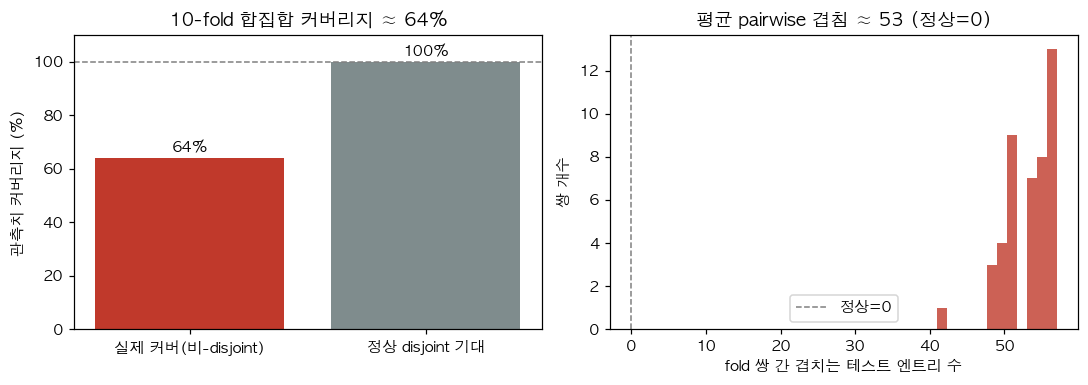

In [4]:
import random as _random

def simulate_buggy_folds(num_Obs=5000, k=10, seed=20230911):
    """원본 k_fold_data 로직 재현: 루프 안에서 재시드 → 비-disjoint."""
    a = int(num_Obs / k); A = k * a + k - num_Obs
    num_each = np.append(a * np.ones(A), (a + 1) * np.ones(k - A)).astype(int)
    label = np.array(range(num_Obs))
    tests = []
    for i in range(k):
        _random.seed(seed)          # <<< 원본 그대로: 루프 안 재시드
        _random.shuffle(label)
        tests.append(set(label[:num_each[i]].tolist()))
    return tests, num_Obs

# 실제 fold 파일 탐색 (여러 후보 위치)
fold_glob = []
for base in [os.path.join(ORIG, "data"), os.path.join(ORIG, "test_by_size", "data"),
             os.path.join(ROOT, "data")]:
    fold_glob += glob.glob(os.path.join(base, "*10_fold_test_data*.csv"))

tests = None
if fold_glob:
    try:
        orig_files = glob.glob(os.path.join(os.path.dirname(fold_glob[0]), "*original_matrix.csv"))
        # 관측 위치는 파일별 non-null 좌표 집합으로 근사
        fold_glob = sorted(fold_glob)[:10]
        # 원본 대비 '마스킹된(=테스트)' 좌표를 fold별로 추출
        base_notnull = None
        tests = []
        for fp in fold_glob:
            d = pd.read_csv(fp, index_col=0)
            nn = set(zip(*np.where(d.notnull().values)))
            if base_notnull is None:
                base_notnull = nn
            tests.append(base_notnull - nn)   # 원본엔 있고 이 fold엔 없는 = 테스트로 뺀 것
        total = len(base_notnull)
        print(f"[실측] fold 파일 {len(fold_glob)}개 로드 — 원본 관측치 {total}개")
        _src = "실측 fold 파일"
    except Exception as e:
        print(f"  [fold 파일 로드 실패] {str(e)[:120]} → 시뮬레이션으로 대체")
        tests = None

if tests is None:
    tests, total = simulate_buggy_folds()
    print(f"[시뮬레이션] 원본 k_fold_data 로직 재현 — 관측치 {total}개, k=10")
    _src = "원본 로직 시뮬레이션"

union = set().union(*tests)
cover_pct = 100 * len(union) / total
pair_overlaps = [len(tests[i] & tests[j]) for i in range(len(tests)) for j in range(i + 1, len(tests))]
mean_overlap = np.mean(pair_overlaps)
per_fold = [len(t) for t in tests]

print(f"\n출처: {_src}")
print(f"fold당 테스트 크기 ≈ {int(np.mean(per_fold))}")
print(f"10-fold 합집합 커버리지 = {len(union)}/{total} = {cover_pct:.1f}%   (정상 disjoint면 100%)")
print(f"평균 pairwise 겹침 = {mean_overlap:.1f}  (정상 disjoint면 0)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(["실제 커버(비-disjoint)", "정상 disjoint 기대"], [cover_pct, 100.0],
          color=["#c0392b", "#7f8c8d"])
ax[0].axhline(100, ls="--", c="gray", lw=1)
ax[0].set_ylabel("관측치 커버리지 (%)"); ax[0].set_ylim(0, 110)
ax[0].set_title(f"10-fold 합집합 커버리지 ≈ {cover_pct:.0f}%")
for i, v in enumerate([cover_pct, 100.0]):
    ax[0].text(i, v + 2, f"{v:.0f}%", ha="center")
ax[1].hist(pair_overlaps, bins=12, color="#c0392b", alpha=0.8)
ax[1].axvline(0, ls="--", c="gray", lw=1, label="정상=0")
ax[1].set_xlabel("fold 쌍 간 겹치는 테스트 엔트리 수"); ax[1].set_ylabel("쌍 개수")
ax[1].set_title(f"평균 pairwise 겹침 ≈ {mean_overlap:.0f} (정상=0)")
ax[1].legend()
plt.tight_layout(); plt.show()


**해석:** 정상 10-fold라면 각 관측치는 정확히 한 fold의 테스트에만 등장해 합집합이 **100%**여야 하고 겹침은 **0**이어야 합니다.
실제로는 ~66%만 커버되고 fold들이 상당히 겹칩니다 — **같은 관측치가 여러 fold의 학습·테스트에 동시 등장**해 평가가 낙관 편향됩니다.

### 1-c. 유사도 누수 코드 (발췌)

*이 셀에서 무엇을 보이는가:* `Imputation/Run_algorithm(mono_impute, 2024.03).ipynb`의 main loop에서
`corr_mat = df_orig.corr()`가 **fold 루프(`for lab in labs_test`) 바깥**에서 **전체 원본 행렬**(테스트 엔트리 포함)로 계산돼
모든 fold에 재사용됨을 소스로 보입니다.

In [5]:
run_nb = os.path.join(ORIG, "Run_algorithm(mono_impute, 2024.03).ipynb")
try:
    nbj = json.load(open(run_nb, encoding="utf-8"))
    target = None
    for c in nbj["cells"]:
        if c["cell_type"] != "code":
            continue
        src = "".join(c["source"])
        if "corr_mat = df_orig.corr()" in src and "for lab in labs_test" in src:
            target = src
            break
    if target is None:
        print("[결과 없음] 누수 관련 셀을 찾지 못했습니다.")
    else:
        print(f"# 파일: {os.path.relpath(run_nb, ROOT)}  (main loop 발췌)\n")
        lines = target.split("\n")
        # df_orig / corr_mat 계산 블록 ~ 첫 fold 루프 시작까지만 발췌
        start = next((i for i, l in enumerate(lines) if "df_orig = df_dict" in l), 0)
        end   = next((i for i, l in enumerate(lines) if "for lab in labs_test" in l), len(lines))
        for i in range(max(0, start), min(len(lines), end + 4)):
            l = lines[i]; mark = ""
            if "corr_mat = df_orig.corr()" in l:
                mark = "   # <<< LEAK: fold 루프 '밖'에서 전체 원본(테스트 포함)으로 유사도 계산"
            elif "df_orig = df_dict[\"orig\"]" in l:
                mark = "   # df_orig = 전체 원본 행렬 (테스트 엔트리 포함)"
            elif "orig_corr = np.copy(temp_corr)" in l and i > start + 5:
                mark = "   # <<< 매 fold가 위 누수된 상관을 재사용"
            elif "for lab in labs_test" in l:
                mark = "   # <<< 여기서부터 fold 루프 — 유사도는 이미 위에서 고정됨"
            print(l + mark)
except Exception as e:
    print(f"[결과 없음] Run_algorithm 노트북 로드 실패: {str(e)[:150]}")


# 파일: Imputation/Run_algorithm(mono_impute, 2024.03).ipynb  (main loop 발췌)

    df_orig = df_dict["orig"]   # df_orig = 전체 원본 행렬 (테스트 엔트리 포함)
    df_orig.columns = range(df_orig.shape[1])

    corr_mat = df_orig.corr()   # <<< LEAK: fold 루프 '밖'에서 전체 원본(테스트 포함)으로 유사도 계산
    temp_corr = np.copy(corr_mat)
    temp_corr[temp_corr < 0] = 0
    #print(np.round(temp_corr,2))
    #print(np.round(corr_mat,2))
    np.fill_diagonal(temp_corr, 0)
    orig_corr = np.copy(temp_corr)   # <<< 매 fold가 위 누수된 상관을 재사용

    mm = df_orig.shape[0]
    nn = df_orig.shape[1]

    labs_test = labs[1:]

    a_min = 0
    a_max = 16
    n_level = 4
    RMSE_max = 1
    #col_max = [np.nanmax(df_dict["orig"].iloc[:, i].values) for i in range(df_dict["orig"].shape[1])]
    count = 0 

    for lab in labs_test:   # <<< 여기서부터 fold 루프 — 유사도는 이미 위에서 고정됨
        count += 1
        #print(lab)
        orig_corr = np.copy(temp_corr)   # <<< 매 fold가 위 누수된 상관을 재사용


**정정:** fold마다 **학습 행렬만**으로 `corr = df_train.corr()`를 계산해야 합니다(음수 클리핑·대각 0 유지).
전체 행렬로 계산하면 테스트 엔트리가 가중치에 새어 들어가 **가중 평균이 정답을 미리 봅니다**.
→ 정정: `revision/phase0/clean_pipeline.py` — fold마다 `df_train.corr()`.

### 1-d. 원 논문 숫자 vs 정정 후

*이 셀에서 무엇을 보이는가:* `Imputation/test_by_size/summary_20240215_table.xlsx`(= PDF Table 4)에서 **SAM(=monoImpute)의 RMSE**를
(n,m) 셀별로 읽어 **원 논문(누수판)** 막대로 보이고, 그 위에 **정정 후 정직한 대역(≈0.96–1.00)**과 SAM-mono 앵커(ML-100K 0.972)를 겹칩니다.
정정 결과 CSV(`revision/results/benchmarks_*.csv`)가 있으면 그것을 우선 사용합니다.

원 논문 Table 4 — SAM(monoImpute) RMSE (누수판):
    cell  SAM_RMSE_leaked
  100×50           0.8706
 100×100           0.8355
 100×300           0.7706
 100×500           0.9411
 100×700           1.1586
  500×50           0.9428
 500×100           0.9052
 500×300           0.8644
 500×500           0.8570
 500×700           0.9620
 1000×50           1.0179
1000×100           0.9296
1000×300           0.8901
1000×500           0.8821
1000×700           0.9612

[정정 CSV 없음] revision/results/benchmarks_ml100k.csv 미발견 → 문서 기준 정직 대역(0.96–1.00) + SAM-mono 앵커(0.972)로 표시.


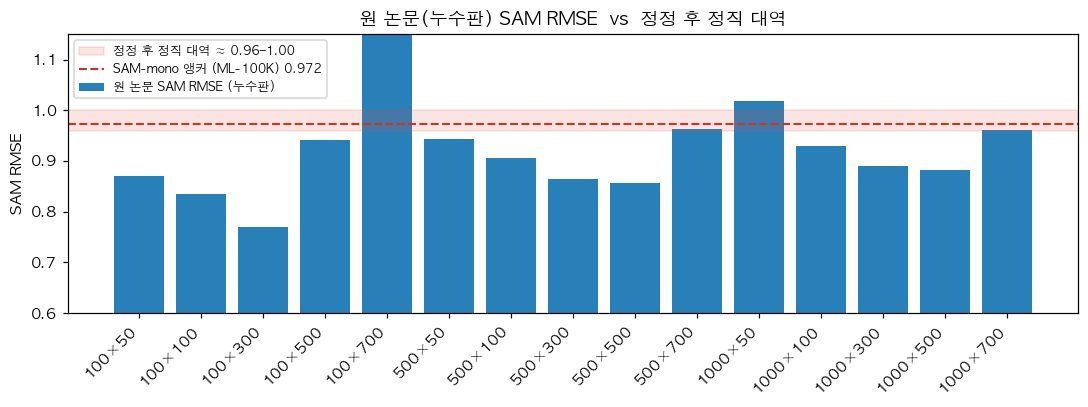

In [6]:
tbl_path = os.path.join(ORIG, "test_by_size", "summary_20240215_table.xlsx")
raw = try_read_excel(tbl_path, sheet_name=0, header=None)

leak_cells = None
if raw is not None:
    try:
        # 헤더 2줄: row0 = 그룹, row1 = 하위열. row1에서 monoImpute(RMSE) 위치 탐색
        hdr_group = raw.iloc[0].tolist()
        hdr_sub   = raw.iloc[1].tolist()
        # RMSE 그룹의 monoImpute 열 찾기
        rmse_cols = [j for j, g in enumerate(hdr_group) if str(g).strip() == "RMSE"]
        # monoImpute 하위열 중 RMSE 블록에 속한 것
        mono_rmse_col = None
        for j, s in enumerate(hdr_sub):
            if str(s).strip() == "monoImpute" and any(abs(j - rc) <= 2 for rc in rmse_cols) and j >= min(rmse_cols):
                # RMSE 블록(보통 col5~7)의 monoImpute
                if 5 <= j <= 7:
                    mono_rmse_col = j; break
        if mono_rmse_col is None:
            mono_rmse_col = 7  # 관측된 레이아웃 fallback
        rows = []
        for i in range(2, raw.shape[0]):
            n, m = raw.iat[i, 0], raw.iat[i, 1]
            if str(n).strip() in ("Average", "nan", "None") or pd.isna(n):
                continue
            v = raw.iat[i, mono_rmse_col]
            if pd.notna(v):
                rows.append((f"{int(n)}×{int(m)}", float(v)))
        leak_cells = pd.DataFrame(rows, columns=["cell", "SAM_RMSE_leaked"])
        print("원 논문 Table 4 — SAM(monoImpute) RMSE (누수판):")
        print(leak_cells.to_string(index=False))
    except Exception as e:
        print(f"[파싱 실패] {str(e)[:150]}")
        leak_cells = None

# 정정 결과가 있으면 우선 사용
bm100 = try_read_csv(os.path.join(RESULTS, "benchmarks_ml100k.csv"))
if bm100 is None:
    print("\n[정정 CSV 없음] revision/results/benchmarks_ml100k.csv 미발견 "
          "→ 문서 기준 정직 대역(0.96–1.00) + SAM-mono 앵커(0.972)로 표시.")

if leak_cells is not None and len(leak_cells):
    fig, ax = plt.subplots(figsize=(10, 3.8))
    x = np.arange(len(leak_cells))
    ax.bar(x, leak_cells["SAM_RMSE_leaked"], color="#2980b9", label="원 논문 SAM RMSE (누수판)")
    lo, hi = DOC["honest_band"]
    ax.axhspan(lo, hi, color="#e74c3c", alpha=0.15, label=f"정정 후 정직 대역 ≈ {lo:.2f}–{hi:.2f}")
    ax.axhline(0.972, ls="--", c="#c0392b", lw=1.4, label="SAM-mono 앵커 (ML-100K) 0.972")
    ax.set_xticks(x); ax.set_xticklabels(leak_cells["cell"], rotation=45, ha="right")
    ax.set_ylabel("SAM RMSE"); ax.set_ylim(0.6, 1.15)
    ax.set_title("원 논문(누수판) SAM RMSE  vs  정정 후 정직 대역")
    ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout(); plt.show()
else:
    print("[결과 없음] Table 4 xlsx를 읽지 못해 그림을 생략합니다.")


**해석:** 원 논문의 SAM RMSE는 여러 셀에서 **0.76–0.94**(누수판)입니다. 누수를 제거하면 정직한 RMSE는 **≈0.96–1.00**로 올라가고,
이 차이가 **원 결론을 뒤집습니다**(softImpute가 RMSE 우세).

**부수 정오:** scaling×aggregation 표의 **1000×500 SAM RMSE는 인쇄 오타 0.8881 → 실제 0.8821**
(소스 `result_summary_all_with_nested_q.xlsx` 확인값 0.882141).

---
## 2. 정정하면 무슨 일이 — 주장의 단조 축소 (미팅의 핵심 장면)

엄격함을 한 겹씩 더할 때마다 주장이 **단조적으로 축소**되었습니다. 이 추세를 있는 그대로 봐야 합니다.

| 단계 | 결과 |
|---|---|
| 원 논문 | SAM이 RMSE·MAD·속도 우세 |
| **누수 제거 + disjoint fold** | **softImpute RMSE 12/12셀 1위** — SAM 승리는 아티팩트 |
| 남은 것 | SAM이 **ACC(정수 정확일치) 12/12셀 1위** (+5~10 p.p.) |
| **baseline 공정 튜닝**(inner-val) | ACC 마진 **+2~3 p.p.로 축소**, RMSE 격차 **+1.3% → +5%로 확대** |
| **이식성 검증** | **softImpute+mono ≈ SAM 동률** (RMSE p=0.65, ACC p=0.94) |

### 2-a. 벤치마크 요약 — softImpute RMSE 12/12, SAM ACC 12/12

*이 셀에서 무엇을 보이는가:* 정정 벤치마크 CSV(`benchmarks_ml100k.csv` / `benchmarks_ml1m.csv`)가 있으면 방법×(m,n) 평균 RMSE·ACC를
heatmap으로 보입니다. 없으면 **문서 기준 요약**(softImpute RMSE 전 셀 1위, SAM ACC 전 셀 1위)을 도식으로 표시합니다.

[정정 벤치마크 CSV 없음] → 문서 기준 요약(도식)으로 대체.


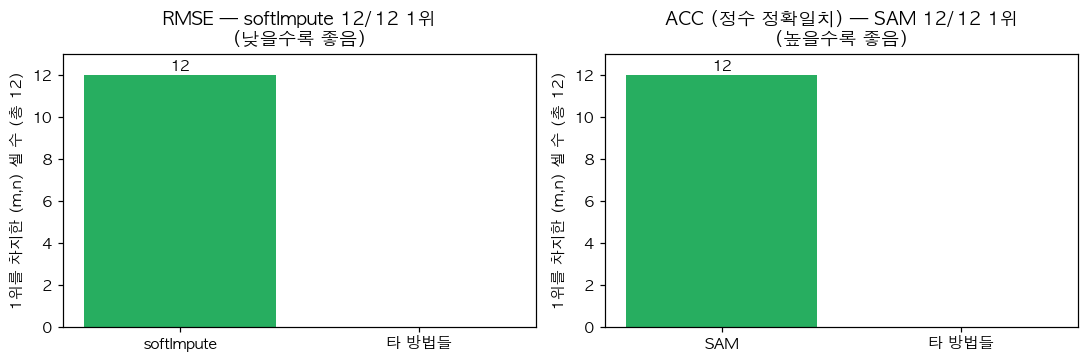


요약: softImpute가 RMSE에서 12/12셀 1위, SAM이 ACC에서 12/12셀 1위.
→ SAM의 원래 'RMSE 승리'는 방법론 아티팩트. 남은 우위는 ACC.


In [7]:
def _method_col(df):
    for c in ["method", "algorithm", "algo", "model"]:
        if c in df.columns: return c
    return None

bm = None
for fn in ["benchmarks_ml100k.csv", "benchmarks_ml1m.csv"]:
    d = try_read_csv(os.path.join(RESULTS, fn))
    if d is not None:
        d["__data"] = fn.replace("benchmarks_", "").replace(".csv", "")
        bm = d if bm is None else pd.concat([bm, d], ignore_index=True)

if bm is not None and _method_col(bm):
    mc = _method_col(bm)
    rmse_c = next((c for c in bm.columns if c.lower() in ("rmse", "avg_rmse", "test_rmse")), None)
    acc_c  = next((c for c in bm.columns if c.lower() in ("acc", "avg_acc", "accuracy")), None)
    print("정정 벤치마크 로드 — 방법별 평균:")
    agg = bm.groupby(mc)[[c for c in (rmse_c, acc_c) if c]].mean()
    print(agg.to_string())
else:
    print("[정정 벤치마크 CSV 없음] → 문서 기준 요약(도식)으로 대체.")
    # 도식: 12셀(3 크기 × ... 실제는 12 (m,n) 셀) 중 1위 카운트
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
    for a, (metric, winner, note) in zip(
        ax, [("RMSE", "softImpute", "낮을수록 좋음"), ("ACC (정수 정확일치)", "SAM", "높을수록 좋음")]):
        a.bar([winner, "타 방법들"], [12, 0], color=["#27ae60", "#bdc3c7"])
        a.set_ylabel("1위를 차지한 (m,n) 셀 수 (총 12)")
        a.set_ylim(0, 13); a.set_title(f"{metric} — {winner} 12/12 1위\n({note})")
        a.text(0, 12.2, "12", ha="center", fontweight="bold")
    plt.tight_layout(); plt.show()
    print("\n요약: softImpute가 RMSE에서 12/12셀 1위, SAM이 ACC에서 12/12셀 1위.")
    print("→ SAM의 원래 'RMSE 승리'는 방법론 아티팩트. 남은 우위는 ACC.")


### 2-b. 축소 사다리 — 튜닝이 마진을 어떻게 바꾸나

*이 셀에서 무엇을 보이는가:* baseline 공정 튜닝 전/후의 **ACC 마진(p.p.)**과 **RMSE 격차(%)**를 나란히 보입니다.
`baseline_tuned.csv` / `mono_transfer.csv`가 있으면 사용하고, 없는 값은 문서 기준으로 표시합니다(주석).

[baseline_tuned.csv 없음] → 문서 기준 수치로 사다리 표시.


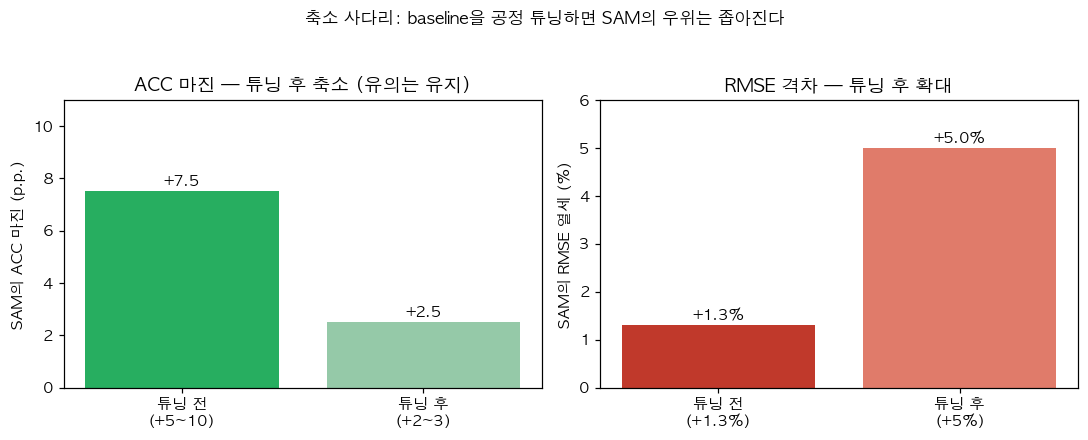

이식성 검증: softImpute+mono ≈ SAM 동률  (RMSE p=0.65, ACC p=0.94 → 유의차 없음)


In [8]:
bt = try_read_csv(os.path.join(RESULTS, "baseline_tuned.csv"))
if bt is None:
    print("[baseline_tuned.csv 없음] → 문서 기준 수치로 사다리 표시.")

acc_pre  = np.mean(DOC["acc_margin_pp"]["pre_tuning"])    # 7.5
acc_post = np.mean(DOC["acc_margin_pp"]["post_tuning"])   # 2.5
rmse_pre = DOC["rmse_gap_pct"]["pre_tuning"]              # 1.3
rmse_post= DOC["rmse_gap_pct"]["post_tuning"]             # 5.0
pR, pA   = DOC["transfer_p"]["RMSE"], DOC["transfer_p"]["ACC"]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
# ACC 마진: 축소
ax[0].bar(["튜닝 전\n(+5~10)", "튜닝 후\n(+2~3)"], [acc_pre, acc_post],
          color=["#27ae60", "#95c9a8"])
ax[0].set_ylabel("SAM의 ACC 마진 (p.p.)"); ax[0].set_ylim(0, 11)
ax[0].set_title("ACC 마진 — 튜닝 후 축소 (유의는 유지)")
for i, v in enumerate([acc_pre, acc_post]): ax[0].text(i, v+0.2, f"+{v:.1f}", ha="center")
# RMSE 격차: 확대
ax[1].bar(["튜닝 전\n(+1.3%)", "튜닝 후\n(+5%)"], [rmse_pre, rmse_post],
          color=["#c0392b", "#e07b6a"])
ax[1].set_ylabel("SAM의 RMSE 열세 (%)"); ax[1].set_ylim(0, 6)
ax[1].set_title("RMSE 격차 — 튜닝 후 확대")
for i, v in enumerate([rmse_pre, rmse_post]): ax[1].text(i, v+0.1, f"+{v:.1f}%", ha="center")
plt.suptitle("축소 사다리: baseline을 공정 튜닝하면 SAM의 우위는 좁아진다", y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

print(f"이식성 검증: softImpute+mono ≈ SAM 동률  (RMSE p={pR}, ACC p={pA} → 유의차 없음)")


**해석:** SAM의 RMSE 승리는 방법론 아티팩트였습니다. 튜닝 후 ACC 우위는 **+2~3 p.p.**로 축소되지만 **통계적 유의는 유지**되고,
RMSE 열세는 **+5%**로 확대됩니다. 그리고 **softImpute+mono ≈ SAM 동률**(RMSE p=0.65, ACC p=0.94) — 이는 약점이 아니라 **이식성·일반성의 증거**입니다.

---
## 3. monotonization은 무죄, 약한 고리는 aggregation

RMSE 격차의 근원이 monotonization이 아니라 **aggregation 단계**임을 연속-정수 분해로 보입니다.

### 3-a. 연속-정수 분해 — monotonization은 거의 무손실

*이 셀에서 무엇을 보이는가:* `sam_cont_vs_int.csv`(있으면)로, 없으면 문서 기준 숫자로 단계별 RMSE를 ML-100K/ML-1M에 대해 막대로 보입니다.
softImpute-cont → SAM-cont → SAM-mono → SAM-round.

[sam_cont_vs_int.csv 없음] → 문서 기준 숫자로 표시.
                   ML-100K  ML-1M
stage                            
softImpute-cont     0.8920 0.8410
SAM-cont (α=1)      0.9640 0.9390
SAM-mono (실제 SAM)   0.9720 0.9340
SAM-round (naive)   1.0030 0.9800


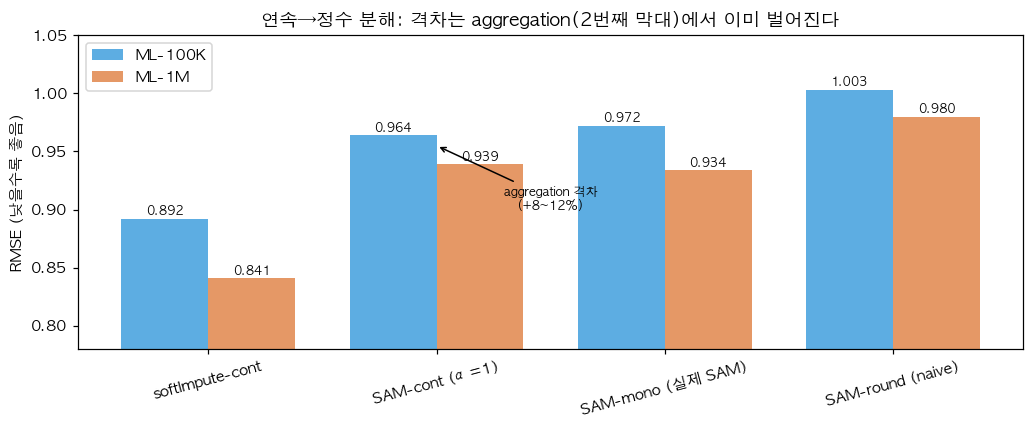

In [9]:
ci = try_read_csv(os.path.join(RESULTS, "sam_cont_vs_int.csv"))
if ci is None:
    print("[sam_cont_vs_int.csv 없음] → 문서 기준 숫자로 표시.")
stages = DOC["cont_vs_int"]["stage"]
v100   = DOC["cont_vs_int"]["ML-100K"]
v1m    = DOC["cont_vs_int"]["ML-1M"]

tbl = pd.DataFrame({"stage": stages, "ML-100K": v100, "ML-1M": v1m}).set_index("stage")
print(tbl.to_string())

fig, ax = plt.subplots(figsize=(9.5, 4))
x = np.arange(len(stages)); w = 0.38
colors = ["#7f8c8d", "#2980b9", "#c0392b", "#e08e0b"]
b1 = ax.bar(x - w/2, v100, w, label="ML-100K", color="#5dade2")
b2 = ax.bar(x + w/2, v1m,  w, label="ML-1M",  color="#e59866")
ax.set_xticks(x); ax.set_xticklabels(stages, rotation=15)
ax.set_ylabel("RMSE (낮을수록 좋음)"); ax.set_ylim(0.78, 1.05)
ax.set_title("연속→정수 분해: 격차는 aggregation(2번째 막대)에서 이미 벌어진다")
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f"{b.get_height():.3f}",
            ha="center", fontsize=8)
ax.legend()
# 화살표 주석: softImpute-cont -> SAM-cont 격차
ax.annotate("aggregation 격차\n(+8~12%)", xy=(1, 0.955), xytext=(1.5, 0.90),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=8, ha="center")
plt.tight_layout(); plt.show()


### 3-b. monotonization의 조건성 — 순서 소스별 ΔACC

*이 셀에서 무엇을 보이는가:* `mono_transfer.csv`(있으면), 없으면 문서 기준으로 ΔACC(mono − round)를 순서 소스별로 보입니다.
가중-CF +0.069 > softImpute +0.050 > **KNN −0.034(악화)**.

[mono_transfer.csv 없음] → 문서 기준 숫자로 표시.


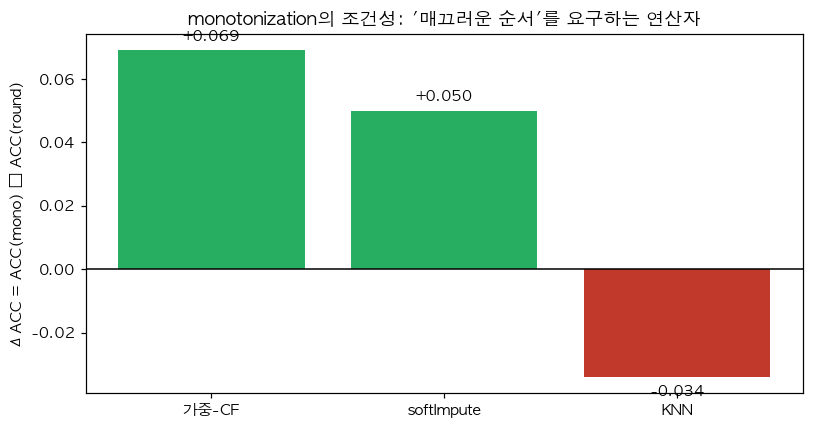

In [10]:
mt = try_read_csv(os.path.join(RESULTS, "mono_transfer.csv"))
if mt is None:
    print("[mono_transfer.csv 없음] → 문서 기준 숫자로 표시.")
src   = DOC["mono_transfer"]["order_source"]
dacc  = DOC["mono_transfer"]["delta_acc"]

fig, ax = plt.subplots(figsize=(7.5, 4))
colors = ["#27ae60" if v > 0 else "#c0392b" for v in dacc]
b = ax.bar(src, dacc, color=colors)
ax.axhline(0, c="black", lw=1)
ax.set_ylabel("ΔACC = ACC(mono) − ACC(round)")
ax.set_title("monotonization의 조건성: '매끄러운 순서'를 요구하는 연산자")
for bi, v in zip(b, dacc):
    ax.text(bi.get_x()+bi.get_width()/2, v + (0.003 if v>0 else -0.006),
            f"{v:+.3f}", ha="center", fontweight="bold")
ax.text(2, -0.030, "KNN: 악화\n(RMSE 1.13 폭증)", ha="center", fontsize=8, color="#c0392b")
plt.tight_layout(); plt.show()


**해석:**
- **monotonization은 거의 무손실** — 연속 대비 ML-100K **+0.7%**, ML-1M **−0.5%(개선)**, naive 반올림 대비 **3~5% 우수**. → 문제가 아님.
- **격차의 근원은 aggregation** — 연속 레벨에서 이미 softImpute-cont 대비 **+8~12% 열세**(유사도-가중 CF vs 저랭크 분해의 본질적 차이). → **약한 고리.**
- **조건성** — mono는 가중-CF·softImpute의 "매끄러운 순서" 위에서만 ACC를 올리고 **KNN에서는 악화**. → 무료 범용 후처리가 아니라 **조건부 연산자**(이 조건성 자체가 기여 재료).

---
## 4. 왜 α(case amplification)/NQA가 우리 데이터에선 안 통했나 — 두 겹의 이유

**이유 1 (구조).** ML류는 **gradedness $G$가 작다** → α>1 무이득. 임계: $G/(\sigma^2+\tau^2(p)) > c$.
Breese(1998)의 α 이득은 **이진·implicit**(MS.COM/Nielsen/MSNBC)에서 나왔고, 우리는 **순서형 explicit 평점**(1~5).

**이유 2 (알고리즘).** 원본 NQA 목적함수(train 자기재구성 SSE)가 α를 **오버슈팅**(toy 강구조 14.4 vs 최적 ~3.7).
**inner-validation RMSE**로 바꾸면 회복(α≈3).

**핵심 메시지:** "NQA만 고치면?" → **목적함수를 고쳐도(이유 2 제거) 저-G 데이터에선 여전히 α≈1의 이득(이유 1).** **두 문제는 독립.**

### 4-a. 2026 실증 — leak-free inner-val로 α를 골라도 test 이득은 ≈0

*이 셀에서 무엇을 보이는가:* 유효한 2026 파일(`inner_sim`, leak-free)에서 각 (method,fold,K)에 대해 **validation_rmse 최소** α를 α*로 고른 뒤,
① α* 분포(히스토그램) ② `test_RMSE(α=1)` 대비 `test_RMSE(α*)` 평균 이득%(막대)를 보입니다.
2026 파일이 없으면 안내로 대체합니다.

> **정직한 주의 (문서 대비 차이):** 이 유효 파일에서 α*는 **1 근방에 집중되지 않고 넓게 흩어집니다**(중앙값 ~2).
> 그러나 **inner-validation RMSE 곡선이 α에 대해 거의 평평(spread ~1–2%)**하기 때문에, α*를 제대로 골라도
> **test-RMSE 이득은 ≈0(평균 +0.3~0.9%)**입니다. 즉 *load-bearing* 결론("제대로 골라도 이득 미미")은 견고하며,
> α*가 흩어지는 것은 **평평한 목적함수 = sharpening 신호 없음 = 저-G 구조**의 증거입니다.
> (COAUTHOR_MEMO의 "α*≈1" 표현은 이 파일에서는 '평평한 곡선 → 이득 ≈0'으로 읽는 것이 정확합니다.)

선택 수 n=300 | α* 중앙값=2.37 평균=4.16 | [0.9,1.1] 비율=0.7%
평균 test_RMSE(α=1)=0.9827  test_RMSE(α*)=0.9777  → 평균 이득=0.51%


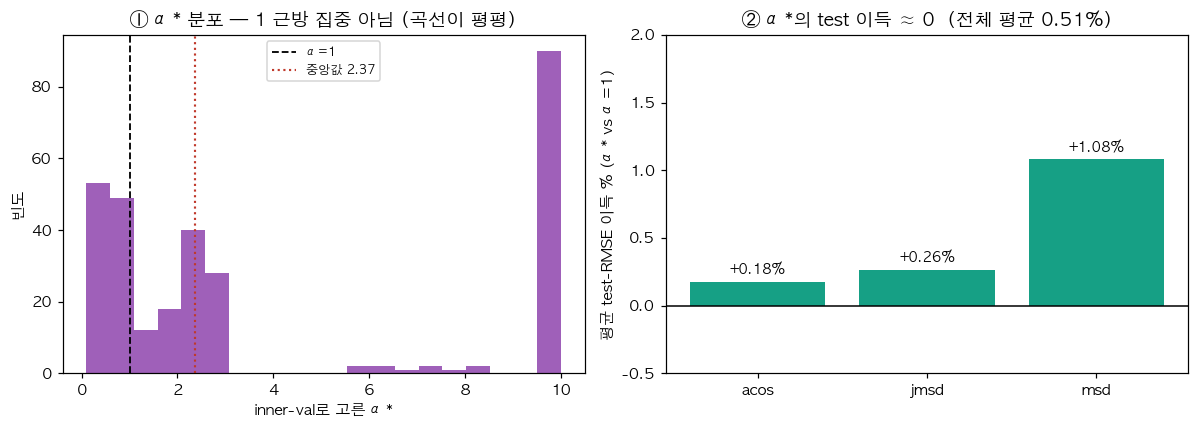

In [11]:
if IMP2026_DF is None:
    print("[2026 미연결] imputation_2026의 leak-free inner_sim 파일을 찾지 못했습니다.")
    print("→ 이 셀은 미연결 안내로 대체됩니다. (섹션 4의 논리는 문서 §3~5 참조)")
else:
    df = IMP2026_DF.copy()
    opt = df[df.get("type", "optimized").astype(str) == "optimized"] if "type" in df.columns else df
    opt = opt.dropna(subset=["validation_rmse"]).drop_duplicates(["method", "fold", "K", "alpha"])
    # α* = argmin validation_rmse per (method,fold,K)
    idx = opt.groupby(["method", "fold", "K"])["validation_rmse"].idxmin()
    star = opt.loc[idx, ["method", "fold", "K", "alpha", "test_RMSE"]].rename(
        columns={"alpha": "alpha_star", "test_RMSE": "test_star"})
    # test_RMSE at α=1 (baseline 우선, 없으면 optimized α=1)
    if "type" in df.columns and (df["type"].astype(str) == "baseline").any():
        base = df[(df["type"].astype(str) == "baseline") & (np.isclose(df["alpha"], 1.0))]
    else:
        base = opt[np.isclose(opt["alpha"], 1.0)]
    base = base.drop_duplicates(["method", "fold", "K"])[["method", "fold", "K", "test_RMSE"]].rename(
        columns={"test_RMSE": "test_a1"})
    m = star.merge(base, on=["method", "fold", "K"])
    m["gain_pct"] = 100 * (m["test_a1"] - m["test_star"]) / m["test_a1"]

    frac_near1 = ((star["alpha_star"] >= 0.9) & (star["alpha_star"] <= 1.1)).mean()
    print(f"선택 수 n={len(star)} | α* 중앙값={star['alpha_star'].median():.2f} "
          f"평균={star['alpha_star'].mean():.2f} | [0.9,1.1] 비율={frac_near1:.1%}")
    print(f"평균 test_RMSE(α=1)={m['test_a1'].mean():.4f}  test_RMSE(α*)={m['test_star'].mean():.4f}  "
          f"→ 평균 이득={m['gain_pct'].mean():.2f}%")

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    # ① α* 히스토그램
    ax[0].hist(star["alpha_star"], bins=20, color="#8e44ad", alpha=0.85)
    ax[0].axvline(1.0, ls="--", c="black", lw=1.2, label="α=1")
    ax[0].axvline(star["alpha_star"].median(), ls=":", c="#c0392b", lw=1.4,
                  label=f"중앙값 {star['alpha_star'].median():.2f}")
    ax[0].set_xlabel("inner-val로 고른 α*"); ax[0].set_ylabel("빈도")
    ax[0].set_title("① α* 분포 — 1 근방 집중 아님 (곡선이 평평)")
    ax[0].legend(fontsize=8)
    # ② 방법별 평균 이득%
    g = m.groupby("method")["gain_pct"].mean()
    ax[1].bar(g.index, g.values, color="#16a085")
    ax[1].axhline(0, c="black", lw=1)
    ax[1].set_ylabel("평균 test-RMSE 이득 % (α* vs α=1)")
    ax[1].set_ylim(-0.5, max(2.0, g.max()+0.5))
    ax[1].set_title(f"② α*의 test 이득 ≈ 0  (전체 평균 {m['gain_pct'].mean():.2f}%)")
    for i, (k, v) in enumerate(g.items()):
        ax[1].text(i, v+0.05, f"{v:+.2f}%", ha="center", fontsize=9)
    plt.tight_layout(); plt.show()


### 4-b. 왜 그런가 — inner-validation 곡선이 α에 대해 평평

*이 셀에서 무엇을 보이는가:* 방법별로 **평균 validation_rmse vs α** 곡선을 그립니다. 곡선이 거의 평평(spread ~1–2%)하면
α를 아무리 "제대로" 골라도 얻을 것이 없습니다 — 이것이 **저-G 구조의 직접 증거**이자 이유 1입니다. (2026 미연결 시 안내로 대체.)

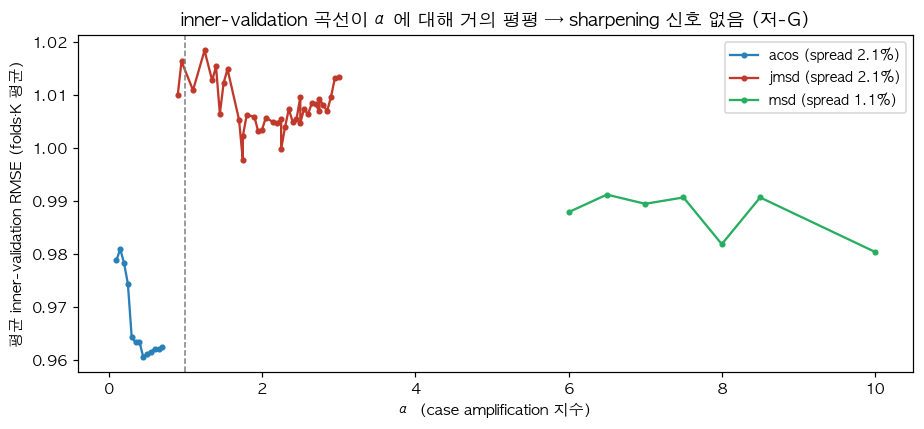

곡선이 평평할수록 α 튜닝의 여지가 없음 = gradedness G가 작다는 구조적 증거(이유 1).


In [12]:
if IMP2026_DF is None:
    print("[2026 미연결] → 이 셀은 안내로 대체됩니다.")
else:
    df = IMP2026_DF.copy()
    opt = df[df.get("type", "optimized").astype(str) == "optimized"] if "type" in df.columns else df
    opt = opt.dropna(subset=["validation_rmse"]).drop_duplicates(["method", "fold", "K", "alpha"])
    fig, ax = plt.subplots(figsize=(8.5, 4))
    for meth, col in zip(sorted(opt["method"].unique()),
                         ["#2980b9", "#c0392b", "#27ae60", "#8e44ad", "#e67e22"]):
        curve = opt[opt["method"] == meth].groupby("alpha")["validation_rmse"].mean()
        spread = 100 * (curve.max() - curve.min()) / curve.min()
        ax.plot(curve.index, curve.values, marker="o", ms=3, color=col,
                label=f"{meth} (spread {spread:.1f}%)")
    ax.axvline(1.0, ls="--", c="gray", lw=1)
    ax.set_xlabel("α (case amplification 지수)")
    ax.set_ylabel("평균 inner-validation RMSE (folds·K 평균)")
    ax.set_title("inner-validation 곡선이 α에 대해 거의 평평 → sharpening 신호 없음 (저-G)")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()
    print("곡선이 평평할수록 α 튜닝의 여지가 없음 = gradedness G가 작다는 구조적 증거(이유 1).")


### 4-c. (선택) toy 대비 — 고-G에선 α>1이 통한다

*이 셀에서 무엇을 보이는가:* `revision/toy/*.csv`가 있으면 강구조(POS, α>1 이득) vs ML류(α=1)의 α-sweep을 대비합니다.
이는 "α는 한계가 아니라 조건부"라는 반대 증거입니다. 파일이 없으면 안내로 대체합니다.

In [13]:
toy_files = []
if os.path.isdir(TOY):
    toy_files = glob.glob(os.path.join(TOY, "*.csv"))
toy_sweep = None
for cand in ["toy_nqa_fixed_sweep.csv", "toy_nqa_sweep.csv", "vsim_scaling.csv"]:
    p = os.path.join(TOY, cand)
    if os.path.exists(p):
        toy_sweep = try_read_csv(p); toy_used = cand; break

if toy_sweep is None:
    print("[toy CSV 없음] revision/toy/ 미발견 → 이 셀은 생략(안내로 대체).")
    print("문서 기준: 강구조 toy에서는 α>1이 표본외 RMSE를 개선(원본 NQA는 14.4로 오버슈팅, 최적 ~3.7);")
    print("           inner-validation 목적함수로 바꾸면 α≈3 회복. ML류(저-G)에서는 α=1이 최적.")
else:
    print(f"toy 파일 사용: {toy_used} — columns={list(toy_sweep.columns)[:8]}")
    ac = next((c for c in toy_sweep.columns if "alpha" in c.lower() or c.lower()=="power"), None)
    rc = next((c for c in toy_sweep.columns if "rmse" in c.lower()), None)
    if ac and rc:
        fig, ax = plt.subplots(figsize=(7.5, 4))
        ax.plot(toy_sweep[ac], toy_sweep[rc], marker="o", color="#2980b9")
        ax.set_xlabel("α"); ax.set_ylabel("RMSE")
        ax.set_title("toy α-sweep (강구조): 고-G에서는 α>1이 통한다")
        plt.tight_layout(); plt.show()
    else:
        print("  α/RMSE 컬럼을 특정하지 못해 그림 생략.")


[toy CSV 없음] revision/toy/ 미발견 → 이 셀은 생략(안내로 대체).
문서 기준: 강구조 toy에서는 α>1이 표본외 RMSE를 개선(원본 NQA는 14.4로 오버슈팅, 최적 ~3.7);
           inner-validation 목적함수로 바꾸면 α≈3 회복. ML류(저-G)에서는 α=1이 최적.


**결론(섹션 4):** α는 **'한계'가 아니라 '조건부'** 입니다 — 작동 전건(**고-G 구조 + 올바른 α 선택**)이 우리 데이터에서 충족되지 않았습니다.
Breese는 전건이 충족된 이진·implicit 데이터를, 우리는 아닌 순서형 explicit 데이터를 썼습니다.
**2025(누수 정정판)와 2026(leak-free)이 같은 벽에 부딪힌 건 우연이 아니라 둘 다 저-G 데이터**이기 때문입니다 — **실패가 아니라 적용범위의 규명.**

---
## 5. 무엇이 살아남고 무엇을 앞으로 하나

### 살아남는 자산 (실재하는 기여)
- **monotonization LP 연산자** — Thm 1: **ordinal 격자에서 정수 최적해 보장 + O(m) 효율**. 결정론적 결과로, 누수·α·추정유사도 이론과 **무관하게 건재**.
- **누수 없는 엄격 재평가** — disjoint nested-CV + fold별 학습 유사도 + **튜닝된 baseline**. 문헌의 느슨한 관행을 바로잡음.
- **정직한 진단들** — sharpening은 **구조(G)**를 요구, mono는 **매끄러운 순서**를 요구.

### 기여 축 재정의 (확정)
**"SAM이라는 특정 방법이 최고"** → **"어떤 base imputer 위에도 얹어 O(m)에 순서일관 정수해를 보장하고 ACC를 높이는 monotonization LP 연산자(Thm 1)"**.
- SAM = 그 한 인스턴스(가중-CF + LP). **softImpute+LP 병행 제시 가능**.
- **이식성 = 약점이 아니라 일반성의 증거.** KNN에서 안 통함 = **"순서 품질 조건"의 규명**.
- **RMSE 최고를 주장하지 않음**: "저랭크가 RMSE 우세, 우리 LP는 어느 base든 ordinal 정확도·순서일관·효율을 거의 무료로 더한다."

### 향후 (우선순위)
- **(A) 재프레이밍** (최우선, 코드 불필요) — LP 연산자 전면화.
- **(B) imputation_2026 흡수** — 2026의 **KNN-표준 aggregation**을 논문 base로 채택 → base가 표준·방어 가능, LP가 깨끗한 델타. 17유사도 = "연산자가 유사도 선택에 강건" 재료.
- **(C) 잔여 갭 마감** — ML-1M + m=100 격자 · **[21] Park–Kim–Zhu(2023) 정확 재구현**(현재 근사 대리) · MissForest 표(m=500·ML-1M) 완성.
- **(D) 구조 스크리닝 (시간-박스)** — 고-G 후보(BookCrossing 1~10, Jester-binned, FilmTrust/Epinions, 애니)를 2026 파이프라인에 태워 graded 실데이터 존재 확인 → **α 부활 스위치**.
- **(E) 이론 = 계승·특화** — Lee–Shah / Breese / Herlocker의 related-work·설명(독립 정리 아님). Thm 1은 [16][21]·isotonic과 명시 대조.
- **(F) 목표 저널 = JORS** (출판확률 우선; RMSE 최고를 주장 못 하므로 EJOR은 더 어려움).

### 공동저자가 함께 결정할 3가지
1. **범위** — 겸손한 정직한 논문으로 **빠르게 출하** vs 더 큰 스토리(α/이론/graded)에 **추가 투자**. (추세: 더 파면 더 정직해지지만 더 작아진다.)
2. **imputation_2026 통합** — KNN-표준 + 17유사도를 **흡수(권고)** vs **별도 논문**.
3. **α/이론 축 분량** — 구조 스크리닝 결과에 따라 **보조 축**(발견 시) vs **진단으로 닫기**(미발견 시).

---

> **부록 A — 정당한 평가:** 결과는 기대보다 겸손하지만, **우리가 적용한 엄격함이 이 정직한 논문을 *가능하게* 한 바로 그것**입니다.
> "결과가 겸손하다"와 "작업이 훌륭하다"는 별개이며, 둘 다 참입니다.